<a href="https://colab.research.google.com/github/PSHASHID/DATA602_Assignment/blob/main/604_Midterm_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import torch
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import pandas as pd

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

Train shape:  (70000, 784)
Test shape:  (10000, 784)
Optimal number of components to explain 85.0% variance: 43


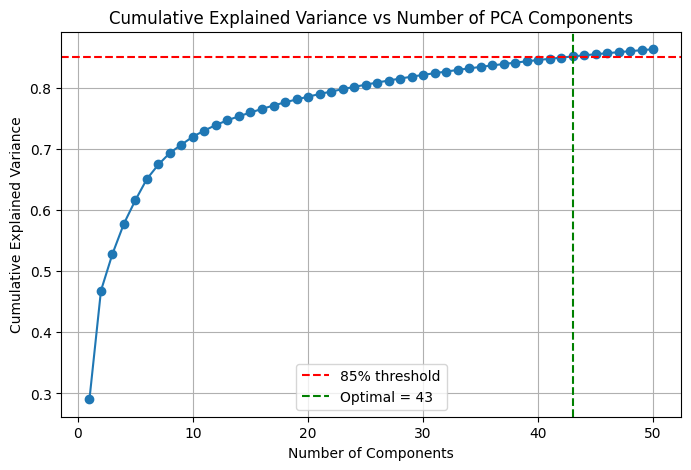

In [15]:
X_train = train_dataset.data.numpy().reshape(-1, 28*28)
y_train = train_dataset.targets.numpy()
X_test = test_dataset.data.numpy().reshape(-1, 28*28)
y_test = test_dataset.targets.numpy()

#Merging train and test sets into X_train and y_train
X_train = np.concat([X_train, X_test], axis = 0)
y_train = np.concat([y_train, y_test], axis = 0)
print("Train shape: ", X_train.shape)
print("Test shape: ", X_test.shape)

#Ideal PCA value calculation.
pca_full = PCA(n_components=50)
pca_full.fit(X_train)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
threshold = 0.85

optimal_components = np.argmax(cum_var >= threshold) + 1
print(f"Optimal number of components to explain {threshold*100}% variance: {optimal_components}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), cum_var, marker='o')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'{int(threshold*100)}% threshold')
plt.axvline(x=optimal_components, color='g', linestyle='--', label=f'Optimal = {optimal_components}')
plt.title("Cumulative Explained Variance vs Number of PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.savefig("optimal_pca_components_plot.png")
plt.show()

In [16]:
# Doing PCA on optimal values and selecting 2 random samples from each class
pca = PCA(n_components=optimal_components)
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
selected_indices = []
labels = y_train
P = pca.components_

for class_label in range(10):
    class_indices = np.where(labels == class_label)[0]
    selected = np.random.choice(class_indices, 2, replace=False)
    selected_indices.extend(selected)

originals = X_train[selected_indices]
labels_subset = labels[selected_indices]
X_centered = originals - pca.mean_

#Computing PCA and reconstructing the images using PCA
projected = np.dot(X_centered, P.T)
reconstructed = np.dot(projected, P) + pca.mean_

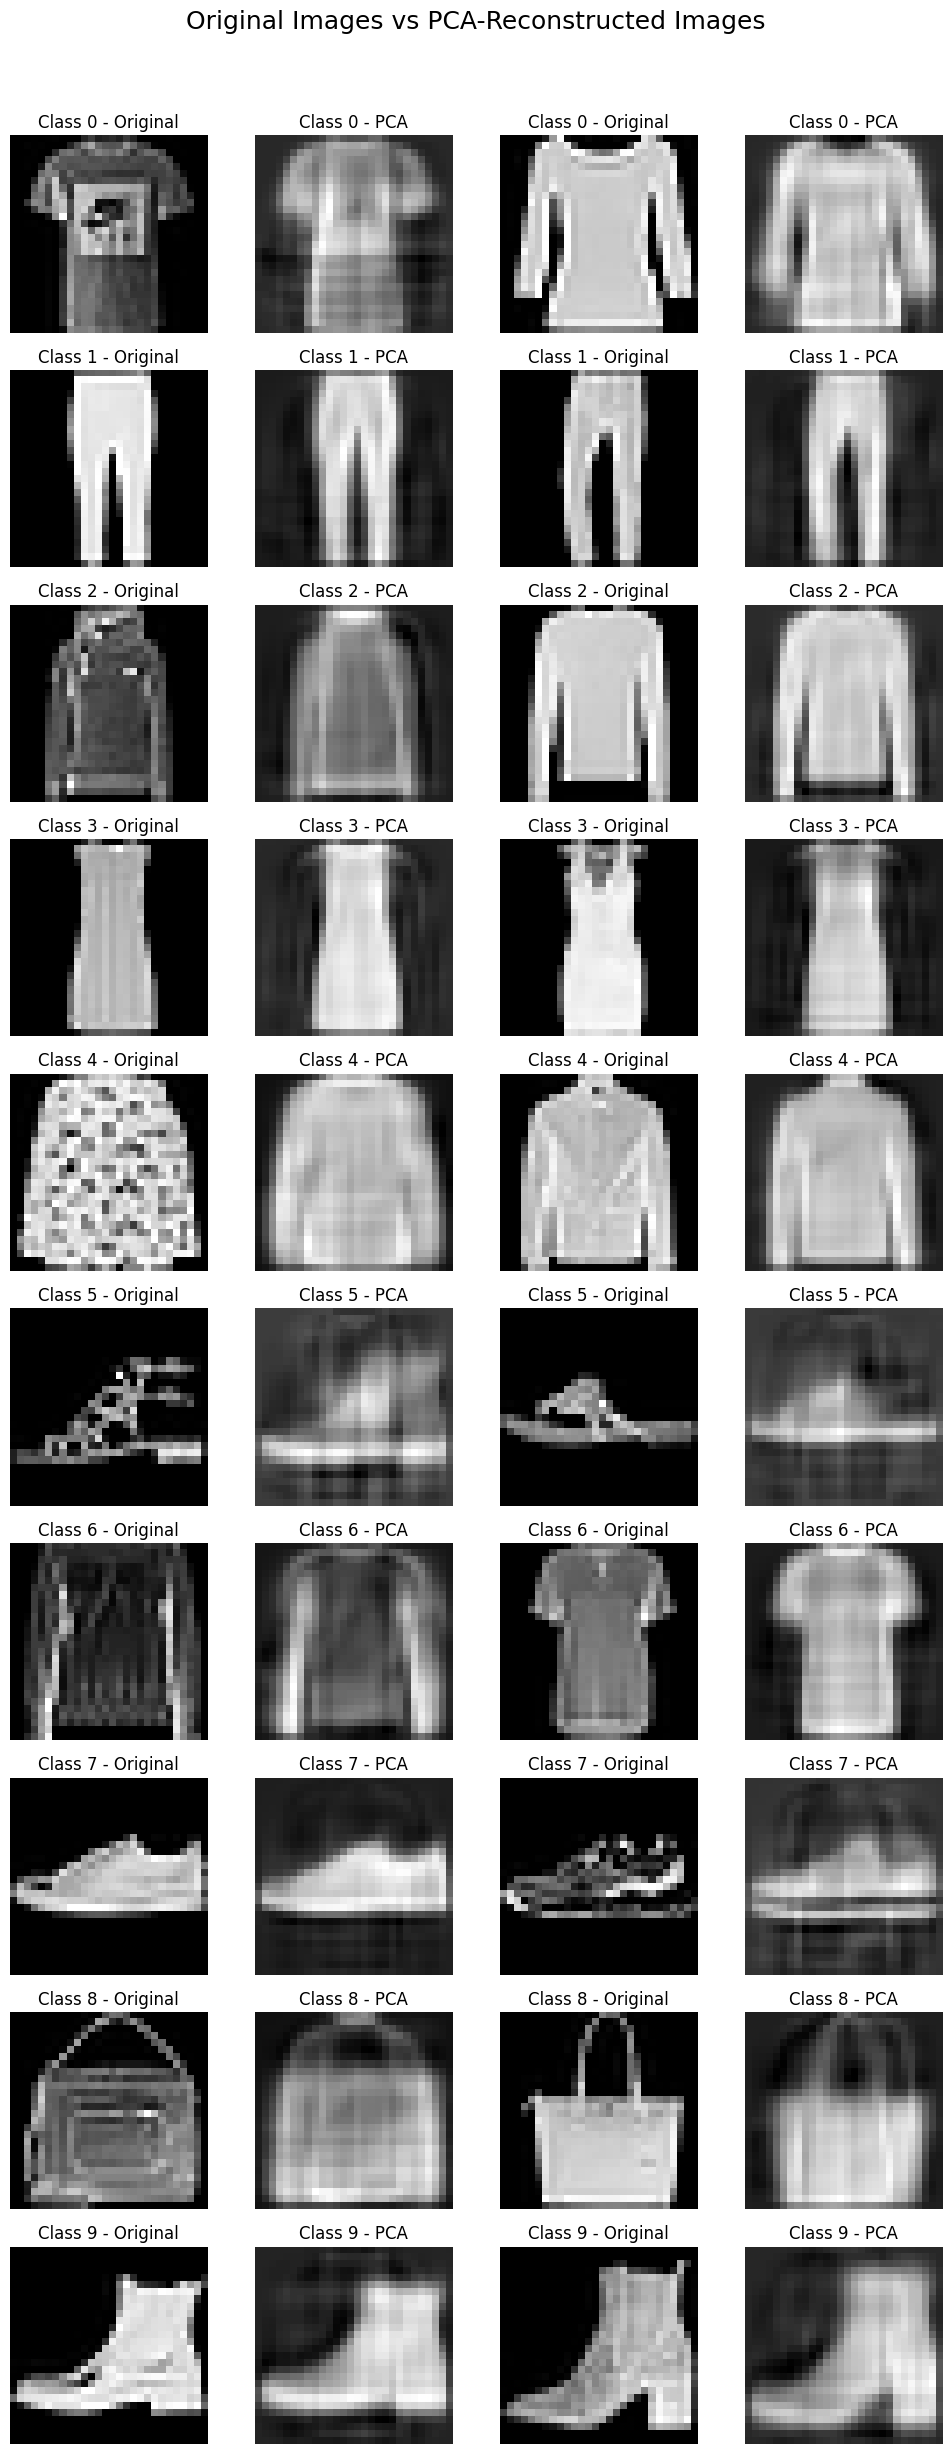

In [17]:
# Plot original vs PCA (reconstructed) images
fig, axes = plt.subplots(10, 4, figsize=(10, 25))
fig.suptitle("Original Images vs PCA-Reconstructed Images", fontsize=18)

for i in range(10):
    for j in range(2):
        idx = i * 2 + j
        orig_img = originals[idx].reshape(28, 28)
        pca_img = reconstructed[idx].reshape(28, 28)

        axes[i, j*2].imshow(orig_img, cmap='gray')
        axes[i, j*2].set_title(f'Class {labels_subset[idx]} - Original')
        axes[i, j*2].axis('off')

        axes[i, j*2+1].imshow(pca_img, cmap='gray')
        axes[i, j*2+1].set_title(f'Class {labels_subset[idx]} - PCA')
        axes[i, j*2+1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("pca_before_after.png")
plt.show()

1b) The Reconstructed images represent the original images well. If the sharpness of the reconstructed images needs to be improved getting more components into the picture will help.

1c) The number of components in PCA is selected by keeping in mind the restriction of chosing components from 1 to 50. While keeping the cumulative explained variance of about 85% we get the ideal number of components to be 43 (from graph). 85% cumulative variance means it exaplains 80% of the total variability in the data.

2) PCA helps improve the accuracy and recall scores of the induvidual classes as shown in the below cell. PCA accuracy comes close to 90% with a minimum accuracy of 86.3% using KNN. While from the previous midterm assignment where only PCA was done we got an accuracy of between the range of 85% to 86.5% for a batch size of N = 6000.


In [18]:
# Reduce both train and test data using PCA
X_test_pca = pca.transform(X_test)

# Select first 6000 images per class for training and last 1000 for testing
def select_subset(X, y, per_class_train=6000, per_class_test=1000):
    train_indices = []
    test_indices = []

    for label in np.unique(y):
        class_indices = np.where(y == label)[0]
        train_indices.extend(class_indices[:per_class_train])
        test_indices.extend(class_indices[-per_class_test:])

    return X[train_indices], y[train_indices], X[test_indices], y[test_indices]

X_train_subset, y_train_subset, X_test_subset, y_test_subset = select_subset(X_train_pca, y_train)

# kNN evaluation for different k values
ks = [5, 10, 15, 20]

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_subset, y_train_subset)
    y_pred = knn.predict(X_test_subset)

    acc = accuracy_score(y_test_subset, y_pred)
    print(f"\nk = {k}")
    print(f"Overall Accuracy: {acc * 100}%")
    print("Per-class metrics:")
    print(classification_report(y_test_subset, y_pred, digits=4))



k = 5
Overall Accuracy: 85.63%
Per-class metrics:
              precision    recall  f1-score   support

           0     0.7793    0.8370    0.8071      1000
           1     0.9827    0.9640    0.9732      1000
           2     0.7435    0.7740    0.7585      1000
           3     0.8880    0.8720    0.8799      1000
           4     0.7527    0.7760    0.7642      1000
           5     0.9750    0.8980    0.9349      1000
           6     0.6580    0.5830    0.6182      1000
           7     0.8969    0.9400    0.9180      1000
           8     0.9668    0.9610    0.9639      1000
           9     0.9194    0.9580    0.9383      1000

    accuracy                         0.8563     10000
   macro avg     0.8562    0.8563    0.8556     10000
weighted avg     0.8562    0.8563    0.8556     10000


k = 10
Overall Accuracy: 85.67%
Per-class metrics:
              precision    recall  f1-score   support

           0     0.7818    0.8490    0.8140      1000
           1     0.9897    0.

3) I used RBF kernel primarily due to its ability to handle non-linear classification such as FashionMNIST.

In [20]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='rbf', decision_function_shape='ovr', verbose=True)
svm_clf.fit(X_train_subset, y_train_subset)

y_pred_svm = svm_clf.predict(X_test_subset)
svm_acc = accuracy_score(y_test_subset, y_pred_svm)

print(f"Overall Accuracy: {svm_acc * 100}%") # using RBF Kernel
print("Per-class matrics:")
print(classification_report(y_test_subset, y_pred_svm, digits=4))

[LibSVM]Overall Accuracy: 87.31%
Per-class matrics:
              precision    recall  f1-score   support

           0     0.8229    0.8550    0.8386      1000
           1     0.9917    0.9570    0.9740      1000
           2     0.7844    0.7860    0.7852      1000
           3     0.8700    0.8900    0.8799      1000
           4     0.7868    0.8010    0.7939      1000
           5     0.9649    0.9350    0.9497      1000
           6     0.6825    0.6450    0.6632      1000
           7     0.9111    0.9430    0.9268      1000
           8     0.9701    0.9740    0.9721      1000
           9     0.9450    0.9450    0.9450      1000

    accuracy                         0.8731     10000
   macro avg     0.8730    0.8731    0.8728     10000
weighted avg     0.8730    0.8731    0.8728     10000

